In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix
from anndata import AnnData
import scanpy as sc
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

def display_anndata_confusion_matrix(adata: AnnData, key1: str, key2: str, save_path: str | None = None):
    y_true = adata.obs[key1].astype(str)
    y_pred = adata.obs[key2].astype(str)

    labels = sorted(list(set(y_true) | set(y_pred)))
    cm_counts = confusion_matrix(y_true, y_pred, labels=labels)
    df_cm_counts = pd.DataFrame(cm_counts, index=labels, columns=labels)

    # Normalize by row to improve visual comparability across classes.
    row_sums = df_cm_counts.sum(axis=1).replace(0, 1)
    df_cm_pct = df_cm_counts.div(row_sums, axis=0) * 100

    # Show both absolute count and row-wise percentage in each cell.
    annot_labels = df_cm_counts.astype(str) + "\n(" + df_cm_pct.round(1).astype(str) + "%)"

    fig_w = max(10, 0.55 * len(labels) + 4)
    fig_h = max(8, 0.45 * len(labels) + 3)
    plt.figure(figsize=(fig_w, fig_h), dpi=130)

    ax = sns.heatmap(
        df_cm_pct,
        annot=annot_labels,
        fmt="",
        cmap="YlGnBu",
        vmin=0,
        vmax=100,
        linewidths=0.6,
        linecolor="white",
        cbar=True,
        cbar_kws={"label": "Row-wise percentage (%)", "shrink": 0.9},
        square=True,
        annot_kws={"fontsize": 9}
    )

    y_label = "nico" if "nico" in key1.lower() else key1
    x_label = "tacco" if "tacco" in key2.lower() else key2
    ax.set_title(f"Confusion Matrix: {y_label} vs {x_label}", fontsize=16, fontweight="bold", pad=15)
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    # Improve annotation contrast in darker cells.
    for text, value in zip(ax.texts, df_cm_pct.to_numpy().flatten()):
        text.set_color("white" if value >= 55 else "black")

    plt.tight_layout()
    #if save_path:
     #   plt.savefig(save_path, format="pdf", bbox_inches="tight")
    plt.show()


In [ ]:
adata_C3_nico= sc.read_h5ad('./C3_nico_2024/nico_celltype_annotation.h5ad')
adata_C3_tacco= sc.read_h5ad('./C3_tacco_2024/adspa_with_tacco_annotation1.h5ad')
adata_C4_nico= sc.read_h5ad('./C4_nico_2024/nico_celltype_annotation.h5ad')
adata_C4_tacco= sc.read_h5ad('./C4_tacco_2024/adspa_with_tacco_annotation1.h5ad')


In [ ]:
adata_C3 = adata_C3_nico.copy()
adata_C4 = adata_C4_nico.copy()

In [ ]:
adata_C3.obs['tacco_celltype'] = adata_C3_tacco.obs['Tacco_pred_cell_type']
adata_C4.obs['tacco_celltype'] = adata_C4_tacco.obs['Tacco_pred_cell_type']

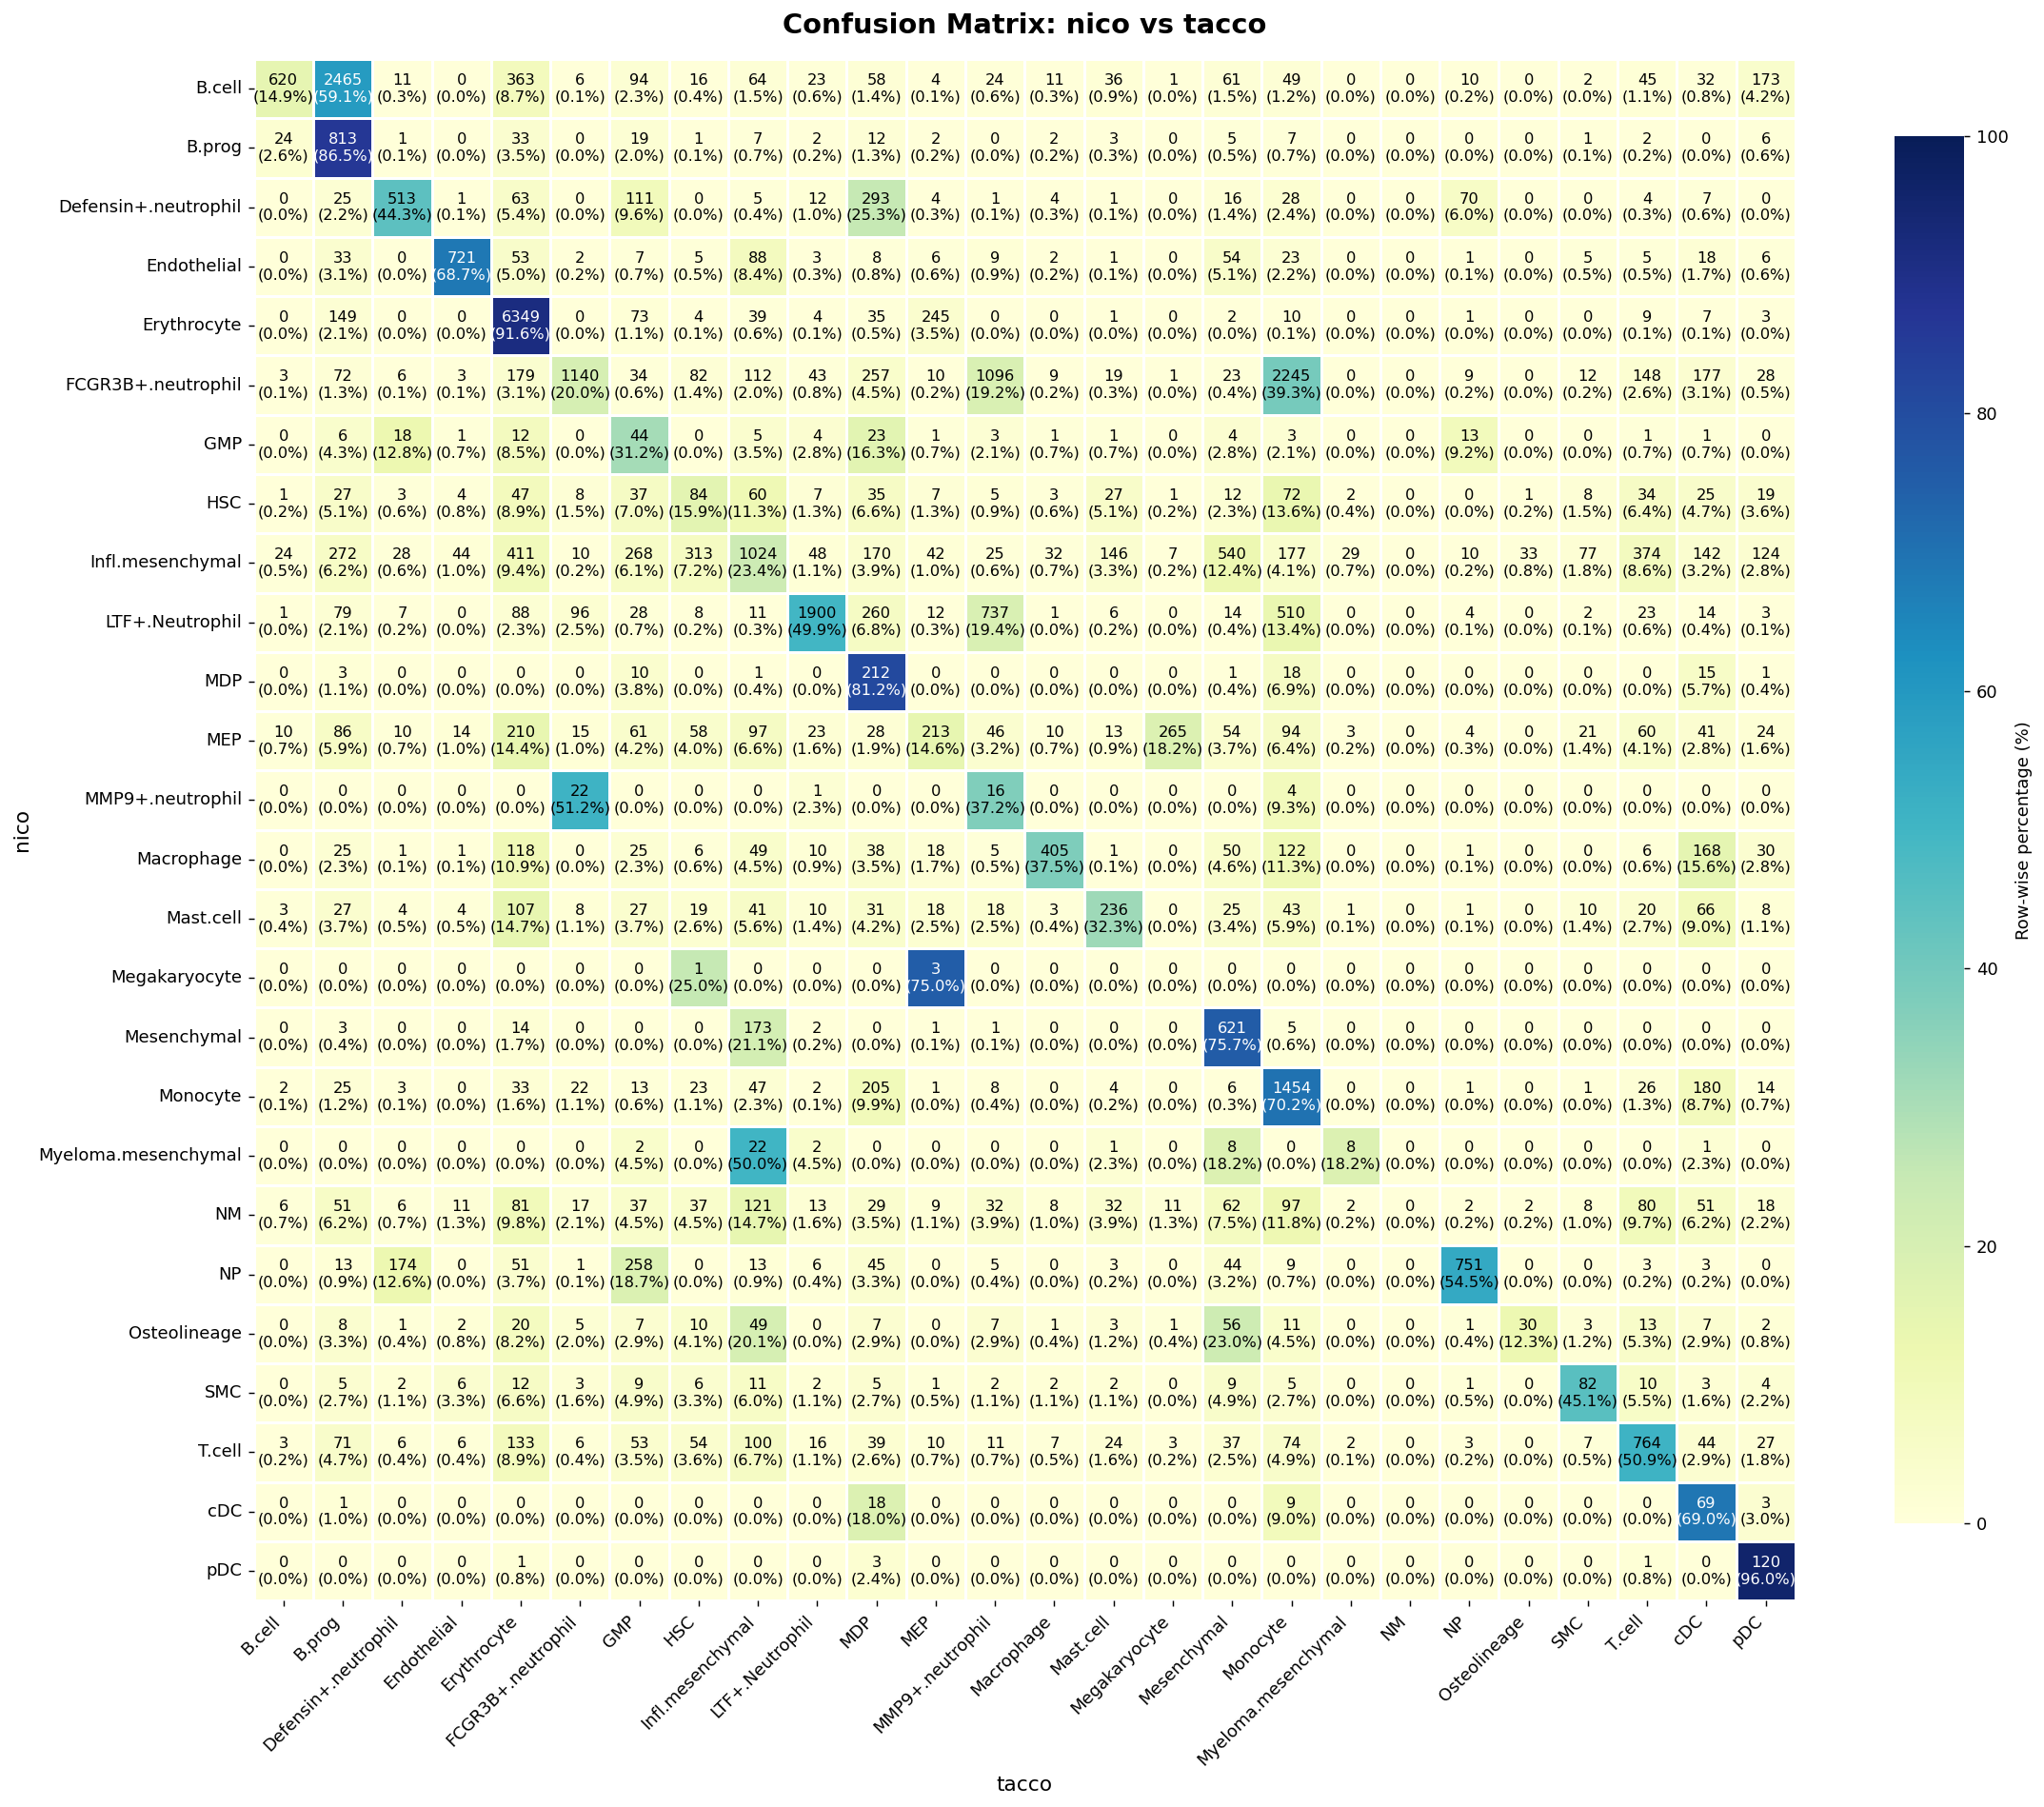

In [ ]:
display_anndata_confusion_matrix(adata_C3, 'nico_ct', 'tacco_celltype', save_path='confusion_matrix_C3_nico_vs_tacco.pdf')

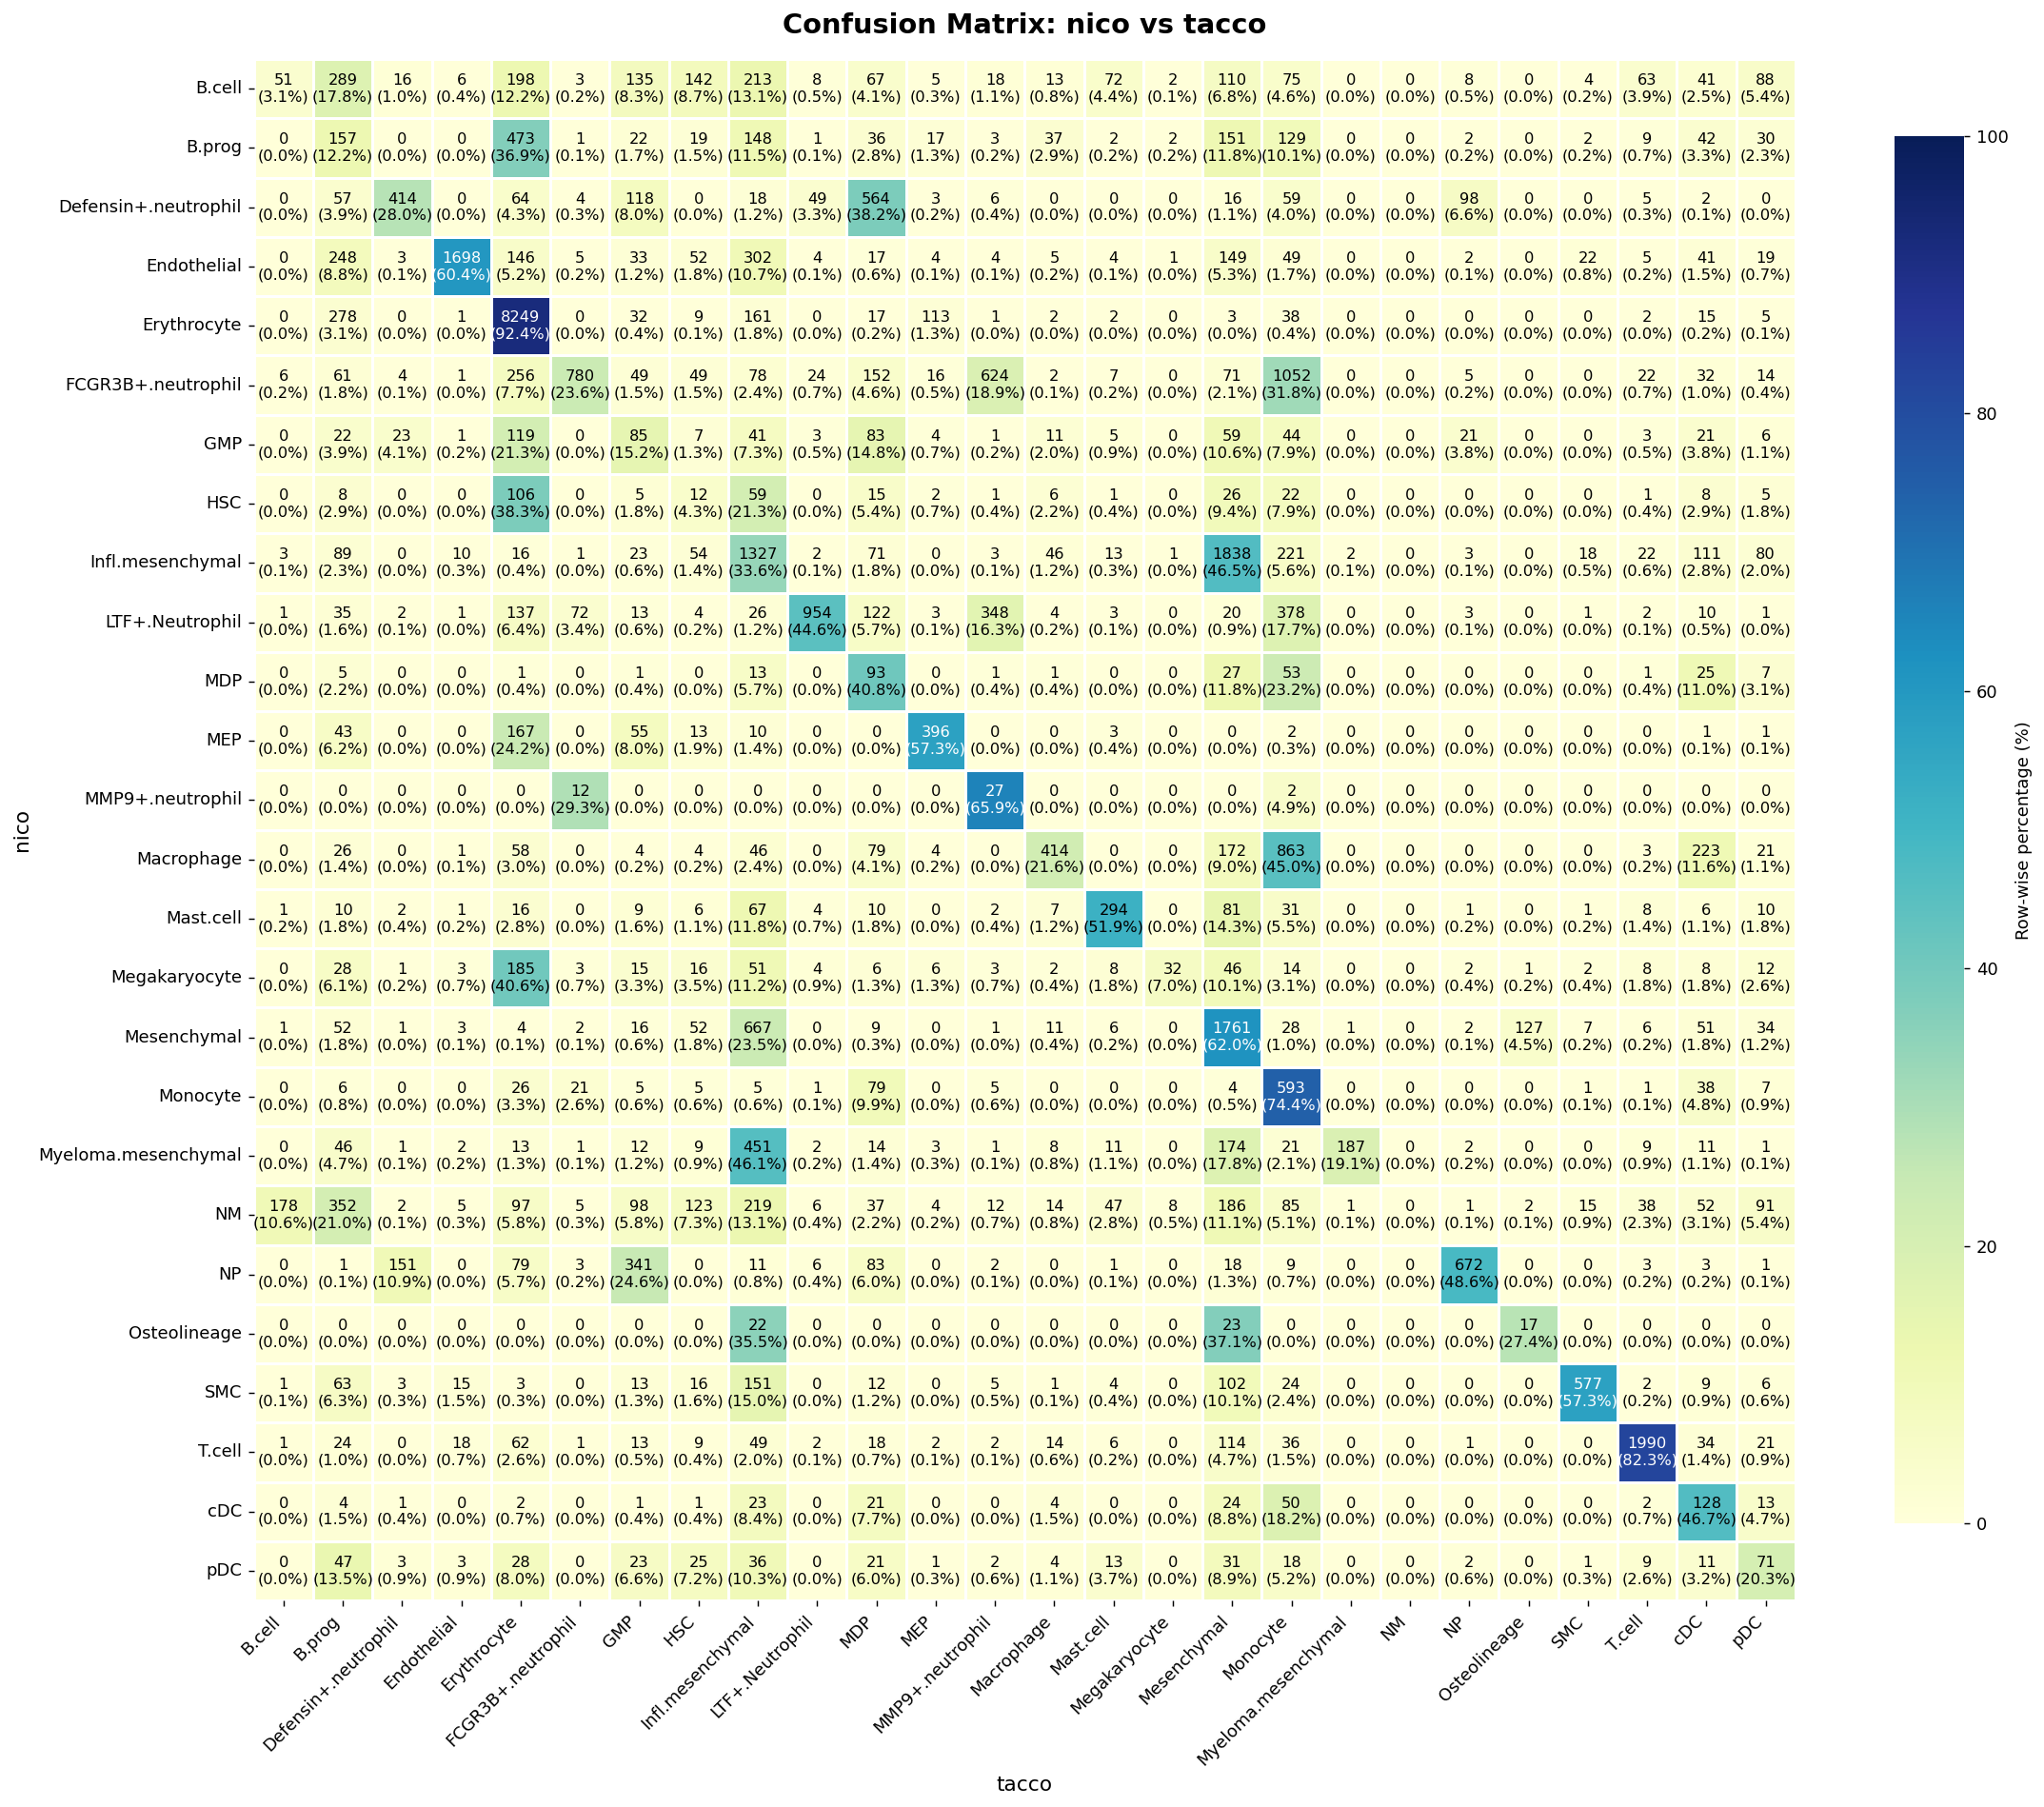

In [ ]:
display_anndata_confusion_matrix(adata_C4, 'nico_ct', 'tacco_celltype', save_path='confusion_matrix_C4_nico_vs_tacco.pdf')